In [3]:
!pip install tensorflow


In [20]:
#Load Datset
import tensorflow as tf
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()
print("Training Images:",x_train.shape)
print("Testing Images:",x_test.shape)


Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [21]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

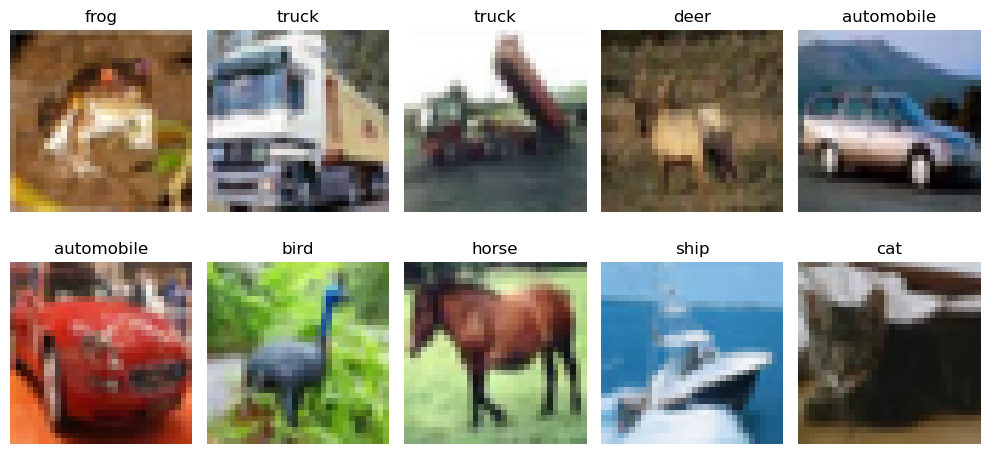

In [22]:
#Sample images of datasets
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
#Normalize Images
x_train_norm=x_train/255.0
x_test_norm=x_test/255.0

In [13]:
#For ANN
x_train_flat=x_train_norm.reshape(len(x_train_norm),-1)
x_test_flat=x_test_norm.reshape(len(x_test_norm),-1)

In [8]:
#Baseline ANN Model
from tensorflow.keras import layers,models
ann_model=models.Sequential([
    layers.Dense(512,activation='relu',input_shape=(3072,)),layers.Dropout(0.3),
    layers.Dense(256,activation='relu'),
    layers.Dense(10,activation='softmax')
])
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann_history=ann_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\BIT\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.2667 - loss: 1.9992 - val_accuracy: 0.3406 - val_loss: 1.8291
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3164 - loss: 1.8664 - val_accuracy: 0.3646 - val_loss: 1.7879
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3286 - loss: 1.8348 - val_accuracy: 0.3704 - val_loss: 1.7600
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3410 - loss: 1.8072 - val_accuracy: 0.3820 - val_loss: 1.7299
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3573 - loss: 1.7670 - val_accuracy: 0.3846 - val_loss: 1.7255
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3693 - loss: 1.7380 - val_accuracy: 0.4078 - val_loss: 1.6903
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3750 - loss: 1.7254 - val_accuracy: 0.4212 - val_loss: 1.6599
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3787 - loss: 1.7078 - 

In [10]:
#CNN Model
cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        10,
        activation='softmax'
    )
])
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 66ms/step - accuracy: 0.4642 - loss: 1.4913 - val_accuracy: 0.4708 - val_loss: 1.5851
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.6069 - loss: 1.1176 - val_accuracy: 0.5136 - val_loss: 1.3560
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.6707 - loss: 0.9387 - val_accuracy: 0.6452 - val_loss: 1.0075
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.7132 - loss: 0.8184 - val_accuracy: 0.7104 - val_loss: 0.8428
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.7469 - loss: 0.7236 - val_accuracy: 0.6666 - val_loss: 0.9975
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.7728 - loss: 0.6507 - val_accuracy: 0.6640 - val_loss: 1.0163
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.7948 - loss: 0.5842 - val_accuracy: 0.7218 - val_loss: 0.8168
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.8121 - loss: 0.5271 - 

In [14]:
#Evaluation between ANN & CNN
ann_loss,ann_acc=ann_model.evaluate(x_test_flat,y_test)
cnn_loss,cnn_acc=cnn_model.evaluate(x_test_norm,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4198 - loss: 1.6600
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6940 - loss: 1.0248


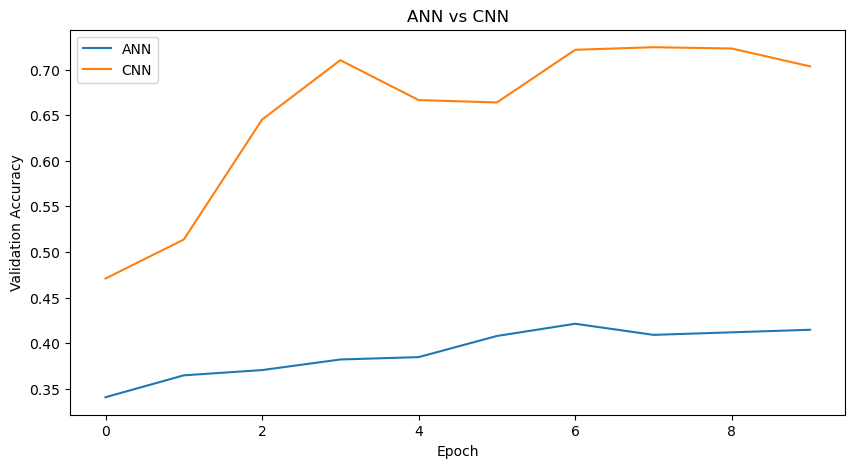

In [15]:
#Validation 
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)
plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN")
plt.legend()

plt.show()

In [16]:
#Advanced Data Augementation Model
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [18]:
aug_cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        3,
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        10,
        activation='softmax'
    )
])
aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.3586 - loss: 1.7514 - val_accuracy: 0.4930 - val_loss: 1.3977
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.4549 - loss: 1.5085 - val_accuracy: 0.5194 - val_loss: 1.3563
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4944 - loss: 1.4159 - val_accuracy: 0.5538 - val_loss: 1.2302
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5207 - loss: 1.3480 - val_accuracy: 0.5890 - val_loss: 1.1474
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.5406 - loss: 1.2963 - val_accuracy: 0.6020 - val_loss: 1.1003
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5515 - loss: 1.2733 - val_accuracy: 0.6244 - val_loss: 1.0530
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.5624 - loss: 1.2424 - val_accuracy: 0.6132 - val_loss: 1.0994
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5752 - loss: 1.2110 - 

In [23]:
#Create a deeper ANN
ann_improved=models.Sequential([
    layers.Dense(1024,activation='relu',input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

In [24]:
#Create CNN
cnn_large = models.Sequential([

    layers.Conv2D(64,(3,3),activation='relu',
                  input_shape=(32,32,3)),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

In [25]:
#Increase epochs
cnn_history_20 = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.8590 - loss: 0.3928 - val_accuracy: 0.7410 - val_loss: 0.8945
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.8731 - loss: 0.3565 - val_accuracy: 0.7450 - val_loss: 0.9041
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.8814 - loss: 0.3296 - val_accuracy: 0.6914 - val_loss: 1.2692
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.8893 - loss: 0.3048 - val_accuracy: 0.7406 - val_loss: 0.9861
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.8971 - loss: 0.2852 - val_accuracy: 0.7446 - val_loss: 0.9941
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.9035 - loss: 0.2648 - val_accuracy: 0.7486 - val_loss: 0.9894
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.9106 - loss: 0.2499 - val_accuracy: 0.7234 - val_loss: 1.1927
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.9132 - loss: 0.2407 - 

In [26]:
#Earlystopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [27]:
#For CNN
cnn_es = models.clone_model(cnn_model)

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_es = cnn_es.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.4627 - loss: 1.5163 - val_accuracy: 0.5580 - val_loss: 1.2567
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.5930 - loss: 1.1648 - val_accuracy: 0.6216 - val_loss: 1.0865
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.6570 - loss: 0.9872 - val_accuracy: 0.5968 - val_loss: 1.2196
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - accuracy: 0.7005 - loss: 0.8643 - val_accuracy: 0.6584 - val_loss: 1.0568
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.7337 - loss: 0.7637 - val_accuracy: 0.6030 - val_loss: 1.2520
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.8196 - loss: 0.5103 - val_accuracy: 0.7212 - val_loss: 0.9030
Epoch 10/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.8372 - loss: 0.4639 - val_accuracy: 0.6704 - val_loss: 1.1238
Epoch 11/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.8492

In [28]:
#Execute Augmented Network Training
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.5926 - loss: 1.1611 - val_accuracy: 0.6478 - val_loss: 0.9925
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5969 - loss: 1.1494 - val_accuracy: 0.6534 - val_loss: 0.9880
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.6019 - loss: 1.1339 - val_accuracy: 0.6504 - val_loss: 1.0030
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6074 - loss: 1.1211 - val_accuracy: 0.6180 - val_loss: 1.1490
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6131 - loss: 1.1050 - val_accuracy: 0.6640 - val_loss: 0.9446
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6153 - loss: 1.1013 - val_accuracy: 0.6682 - val_loss: 0.9417
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6160 - loss: 1.0969 - val_accuracy: 0.6628 - val_loss: 0.9557
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.6203 - loss: 1.0835 - 

In [35]:
es_loss, es_acc = cnn_es.evaluate(
    x_test_norm,
    y_test
)

print("CNN + EarlyStopping Accuracy:", es_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7200 - loss: 0.8373
CNN + EarlyStopping Accuracy: 0.7200000286102295


In [37]:
#Final Comparison Table
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "ANN",
        "Improved ANN",
        "CNN",
        "CNN Large Filters",
        "CNN EarlyStopping",
        "CNN Augmentation"
    ],
    "Test Accuracy": [
        ann_acc,
        ann_improved_acc,
        cnn_acc,
        cnn_large,
        es_acc,
        aug_acc
    ]
})

results

,Model,Test Accuracy
0,ANN,0.4198
1,Improved ANN,0.1083
2,CNN,0.694
3,CNN Large Filters,"<Sequential name=sequential_7, built=True>"
4,CNN EarlyStopping,0.72
5,CNN Augmentation,0.6891


# Conclusion

In this project, image classification was performed on the CIFAR-10 dataset using both Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN). The dataset was preprocessed by normalizing pixel values to improve training stability and convergence.

The baseline ANN model was able to classify images with reasonable accuracy, but its performance was limited because the images were flattened into one-dimensional vectors, causing the loss of important spatial information. In contrast, the CNN model achieved significantly higher accuracy by preserving spatial relationships through convolution and pooling operations. CNN layers were able to automatically learn meaningful visual features such as edges, textures, and object patterns.

Several training strategies were also explored. Increasing the number of dense layers in the ANN improved performance slightly, while increasing CNN filter sizes enhanced feature extraction capability. Training the models for more epochs allowed them to learn richer representations, although excessive training may lead to overfitting. The EarlyStopping technique helped prevent unnecessary training and improved generalization by restoring the best model weights. Data augmentation further improved robustness by exposing the model to transformed versions of the training images.

Overall, CNN-based models consistently outperformed ANN-based models on the CIFAR-10 dataset. Among all experiments, the augmented CNN achieved the best generalization performance, demonstrating the importance of convolutional architectures and effective training strategies in image classification tasks.
